# GP-PHS: Nonlinear Controlled 2-DOF Port-Hamiltonian Oscillator

### A 4-State Port-Hamiltonian System with State-Dependent Interconnection, Damping, and Input Coupling


The Hamiltonian of the system is

$$
H(q_1,q_2,p_1,p_2)
=
\frac{1}{2}\left(K_1 q_1^2 + K_2 q_2^2\right)
+
\frac{1}{2}\left(\frac{p_1^2}{M_1} + \frac{p_2^2}{M_2}\right)
$$

where

- $q_1, q_2$ are the generalized coordinates,
- $p_1, p_2$ are the generalized momenta,
- $K_1, K_2$ are the spring constants,
- $M_1, M_2$ are the masses.

## Mathematical Formulation

### Interconnection Matrix (State-Dependent)
$$
J(x) = \begin{bmatrix}
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
-1 & 0 & 0 & \alpha q_1 q_2 \\
0 & -1 & -\alpha q_1 q_2 & 0
\end{bmatrix}
$$

Check: $J(x)^T = -J(x)$ (skew-symmetric) ✓

**Parameter**: $\alpha$ (coupling strength)

### Dissipation Matrix (State-Dependent & PSD)
$$
R(x) = \begin{bmatrix}
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & b_1 + b_2 q_1^2 & 0 \\
0 & 0 & 0 & b_3 + b_4 q_2^2
\end{bmatrix}
$$

This guarantees $R(x) \succeq 0$. **Parameters**: $b_1, b_2, b_3, b_4 > 0$

### Input Matrix (State-Dependent)
$$
G(x) = \begin{bmatrix}
0 & 0 \\
0 & 0 \\
1 + \beta q_1^2 & 0 \\
0 & 1 + \gamma q_2^2
\end{bmatrix}
$$

**Parameters**: $\beta, \gamma$ (input coupling modulation)

### Complete Dynamics
$$
\dot{x} = \bigl(J(x) - R(x)\bigr)\nabla H(x) + G(x) u
$$

### Parameters to Learn
$$
\theta = \{b_1, b_2, b_3, b_4, \alpha, \beta, \gamma\} \quad \text{(7 parameters)}
$$


### Install (Colab only)
Skip this step when running locally.

In [65]:
# ── Google Colab / fresh environment setup ──────────────────────────────────
# !pip install -q git+https://github.com/essey1/neuromancer.git gpytorch scipy

## Imports

In [66]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve() / "src"))

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import gpytorch
from scipy.integrate import odeint
from torch.utils.data import DataLoader

from neuromancer import psl
from neuromancer import dataset
from neuromancer.psl import plot
from neuromancer.dynamics import gp_phs, ode
from neuromancer.psl import gp_smoother
from neuromancer.modules import hamiltonian_approximator
from neuromancer.system import Node, System
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.loss import AugmentedLagrangeLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.loggers import BasicLogger

torch.manual_seed(0); np.random.seed(0)

## Configuration

In [ ]:
# ============================================================
# DATA & TRAINING HYPERPARAMETERS
# ============================================================
N_POINTS = 250         # per trajectory; total = N_POINTS * len(X0_TRAIN)
NOISE    = 0.05        # sensor noise std
N_EPOCHS = 2000         
NX, NU   = 4, 2
T_SIM    = 15.0        # simulation time
X0_TRAIN = [
    [0.2, 0.0, 1.5, 0.0],   # b1
    [3.0, 0.0, 1.5, 0.0],   # b2 + beta
    [0.0, 0.2, 0.0, 1.5],   # b3
    [0.0, 3.0, 0.0, 1.5],   # b4 + gamma
    [2.0, 2.0, 1.0, 1.0],   # alpha (strong coupling)
    [3.0, 2.0, 1.5, 1.0],   # all parameters excited
]
X0_TEST = [
    [2.2, 1.6, 1.1, 0.9],
    [1.0, 1.0, 0.7, 0.7],
    [2.5, 1.8, 1.2, 1.0], 
]

# ============================================================
# TRUE SYSTEM PARAMETERS
# ============================================================
# Masses and stiffnesses
M1_TRUE  = 1.0
M2_TRUE  = 1.2
K1_TRUE  = 2.0
K2_TRUE  = 2.5

# Dissipation (state-independent + state-dependent)
B1_TRUE  = 0.15      # constant damping p1
B2_TRUE  = 0.08      # velocity-dependent damping p1
B3_TRUE  = 0.12      # constant damping p2
B4_TRUE  = 0.10      # velocity-dependent damping p2

# Interconnection and input coupling (all physical: ≥ 0)
ALPHA_TRUE = 0.05    # state-dependent coupling J(x)[2,3]
BETA_TRUE  = 0.04    # input effectiveness modulation u1
GAMMA_TRUE = 0.06    # input effectiveness modulation u2

# Input signal parameters (rich excitation for identifiability)
INPUT_AMP1 = 3.0     # amplitude of u1
INPUT_AMP2 = 2.0     # amplitude of u2
INPUT_FREQ1_A = 0.7  # frequency 1 for u1
INPUT_FREQ1_B = 2.3  # frequency 2 for u1
INPUT_FREQ2_A = 1.1  # frequency 1 for u2
INPUT_FREQ2_B = 3.7  # frequency 2 for u2

## True System

### Define true dynamics

In [68]:
# Define true system parameters
true_params = {
    'm1': M1_TRUE, 'm2': M2_TRUE,
    'k1': K1_TRUE, 'k2': K2_TRUE,
    'b1': B1_TRUE, 'b2': B2_TRUE, 'b3': B3_TRUE, 'b4': B4_TRUE,
    'alpha': ALPHA_TRUE, 'beta': BETA_TRUE, 'gamma': GAMMA_TRUE
}

def H_true(q1, q2, p1, p2):
    """Hamiltonian energy"""
    return (K1_TRUE * q1**2 + K2_TRUE * q2**2) / 2.0 + (p1**2 / M1_TRUE + p2**2 / M2_TRUE) / 2.0

def grad_H_true(state):
    """Gradient of Hamiltonian"""
    q1, q2, p1, p2 = state
    return np.array([
        K1_TRUE * q1,
        K2_TRUE * q2,
        p1 / M1_TRUE,
        p2 / M2_TRUE
    ])

def J_true(state):
    """Skew-symmetric interconnection matrix J(x)"""
    q1, q2, p1, p2 = state
    return np.array([
        [0,    0,    1,           0           ],
        [0,    0,    0,           1           ],
        [-1,   0,    0,           ALPHA_TRUE * q1 * q2],
        [0,   -1,   -ALPHA_TRUE * q1 * q2,   0           ]
    ])

def R_true(state):
    """Dissipation matrix R(x) [diagonal]"""
    q1, q2, p1, p2 = state
    return np.diag([
        0.0,
        0.0,
        B1_TRUE + B2_TRUE * q1**2,
        B3_TRUE + B4_TRUE * q2**2
    ])

def G_true(state):
    """Input matrix G(x)"""
    q1, q2, p1, p2 = state
    return np.array([
        [0,                      0                      ],
        [0,                      0                      ],
        [1.0 + BETA_TRUE * q1**2, 0                      ],
        [0,                      1.0 + GAMMA_TRUE * q2**2]
    ])

def input_signal(t):
    """Time-dependent input signal u(t)"""
    u1 = INPUT_AMP1 * np.sin(INPUT_FREQ1_A * t) + 0.6 * np.sin(INPUT_FREQ1_B * t)
    u2 = INPUT_AMP2 * np.cos(INPUT_FREQ2_A * t) + 0.6 * np.sin(INPUT_FREQ2_B * t)
    return np.array([u1, u2])

def dynamics(state, t, sig=input_signal):
    """Complete PHS dynamics: ẋ = (J-R)∇H + Gu"""
    grad_h = grad_H_true(state)
    J = J_true(state)
    R = R_true(state)
    G = G_true(state)
    u = sig(t)
    return (J - R) @ grad_h + G @ u

### Plot true trajectory

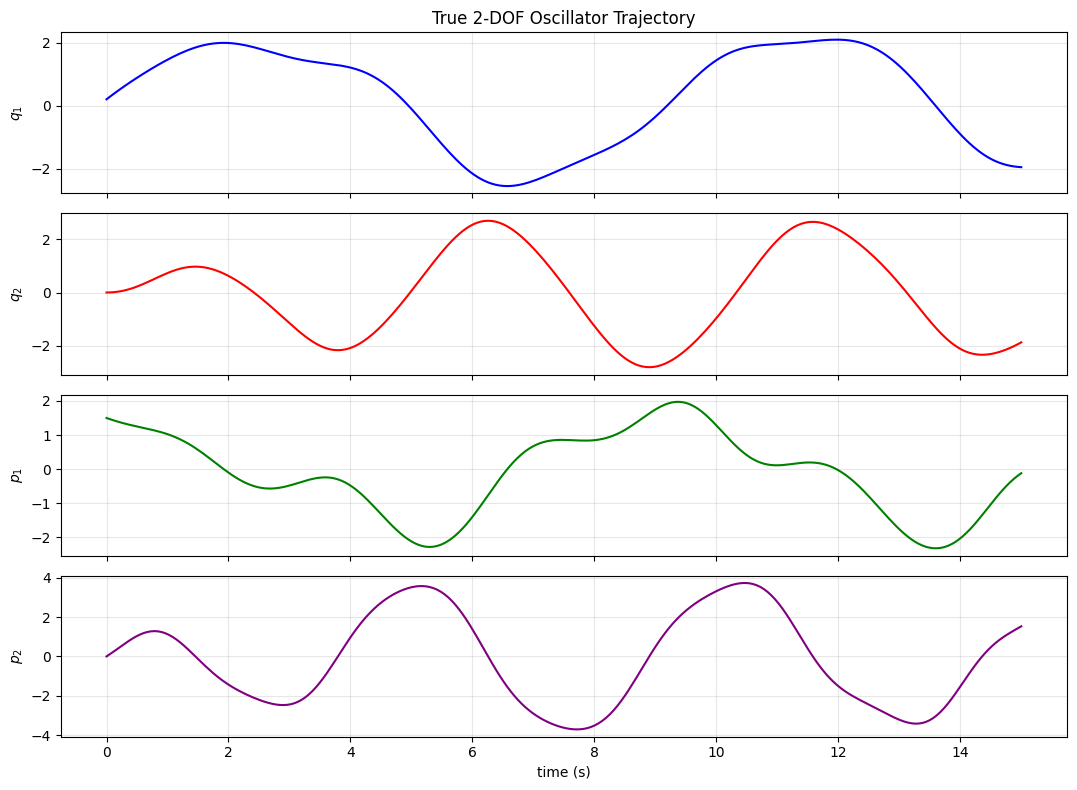

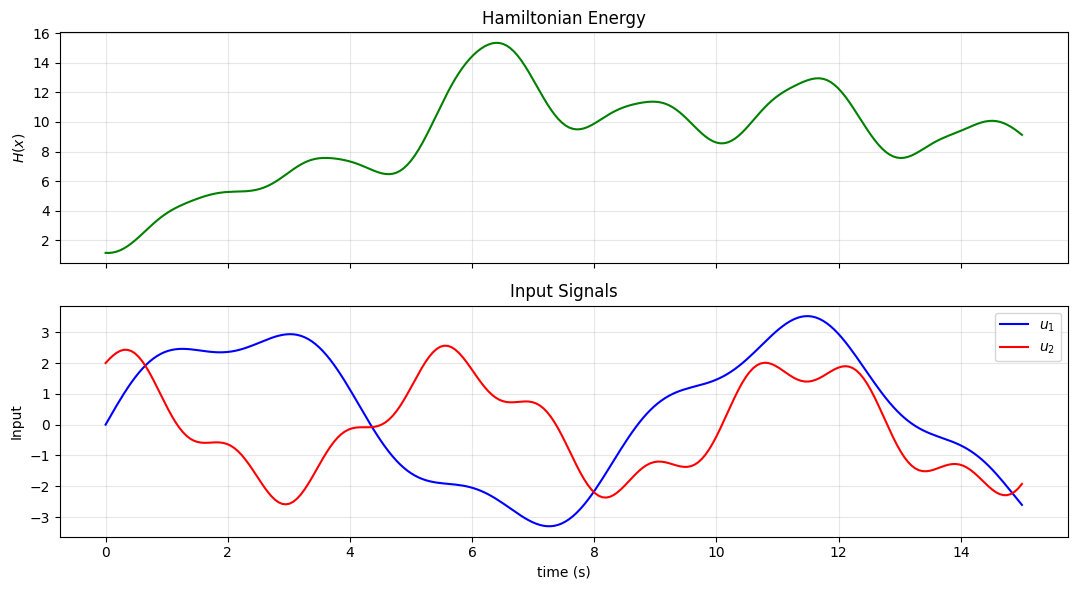

In [116]:
# Plot the large amplitude trajectory (trajectory 1)
x0  = X0_TRAIN[0]
t_i = np.linspace(0, T_SIM, N_POINTS)
traj_i = odeint(lambda state, t, s=input_signal: dynamics(state, t, s), x0, t_i)
u_i    = np.array([input_signal(t) for t in t_i])
H_i    = np.array([H_true(x[0], x[1], x[2], x[3]) for x in traj_i])

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
labels = [r'$q_1$', r'$q_2$', r'$p_1$', r'$p_2$']
colors = ['b', 'r', 'g', 'purple']
for j, (ax, lbl, col) in enumerate(zip(axes, labels, colors)):
    ax.plot(t_i, traj_i[:, j], col, lw=1.5)
    ax.set_ylabel(lbl); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('time (s)')
axes[0].set_title('True 2-DOF Oscillator Trajectory')
plt.tight_layout(); plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(t_i, H_i, 'g', lw=1.5)
ax1.set_ylabel(r'$H(x)$'); ax1.grid(True, alpha=0.3)
ax1.set_title('Hamiltonian Energy')
ax2.plot(t_i, u_i[:, 0], 'b', label=r'$u_1$', lw=1.5)
ax2.plot(t_i, u_i[:, 1], 'r', label=r'$u_2$', lw=1.5)
ax2.set_ylabel('Input'); ax2.set_xlabel('time (s)'); ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_title('Input Signals')
plt.tight_layout(); plt.show()

## Step 1: Dataset Preparation

### Data Sampling & Dataset Preparation

Simulate trajectories from multiple initial conditions, add sensor noise, and apply GP smoothing to estimate derivatives $\dot{x}$ and their uncertainty $\Delta$. The result is split into train/dev/test DataLoaders ready for training.

In [124]:
# DATA GENERATION
sigs = [input_signal] * len(X0_TRAIN)
trajs_true, trajs, us, t_all = [], [], [], []
for i, (x0, sig) in enumerate(zip(X0_TRAIN, sigs)):
    t_i = np.linspace(i * T_SIM, (i + 1) * T_SIM, N_POINTS)
    x_i = odeint(lambda state, t, s=sig: dynamics(state, t, s), x0, t_i)
    u_i = np.array([sig(t) for t in t_i])
    trajs_true.append(x_i)
    x_noisy_i = x_i + np.random.normal(0, NOISE, x_i.shape)
    trajs.append(x_noisy_i); us.append(u_i); t_all.append(t_i)

# GP SMOOTHER
smoothed, xdots, xdot_vars = [], [], []
for t_i, x_i in zip(t_all, trajs):
    x_s, xd, xdv = gp_smoother.gp_smooth(t_i, x_i)
    smoothed.append(x_s); xdots.append(xd); xdot_vars.append(xdv)

# DATA LOADERS
train_loader, dev_loader, test_loader = dataset.gpphs_data_from_arrays(
    x=np.concatenate(smoothed),
    x_dot=np.concatenate(xdots),
    u=np.concatenate(us),
    x_dot_var=np.concatenate(xdot_vars),
    split_ratio=[75.0, 15.0, 10.0],
    batch_size=len(X0_TRAIN) * N_POINTS,
)

C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)
C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gpytorch\models\exact_gp.py:299: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


### Plot

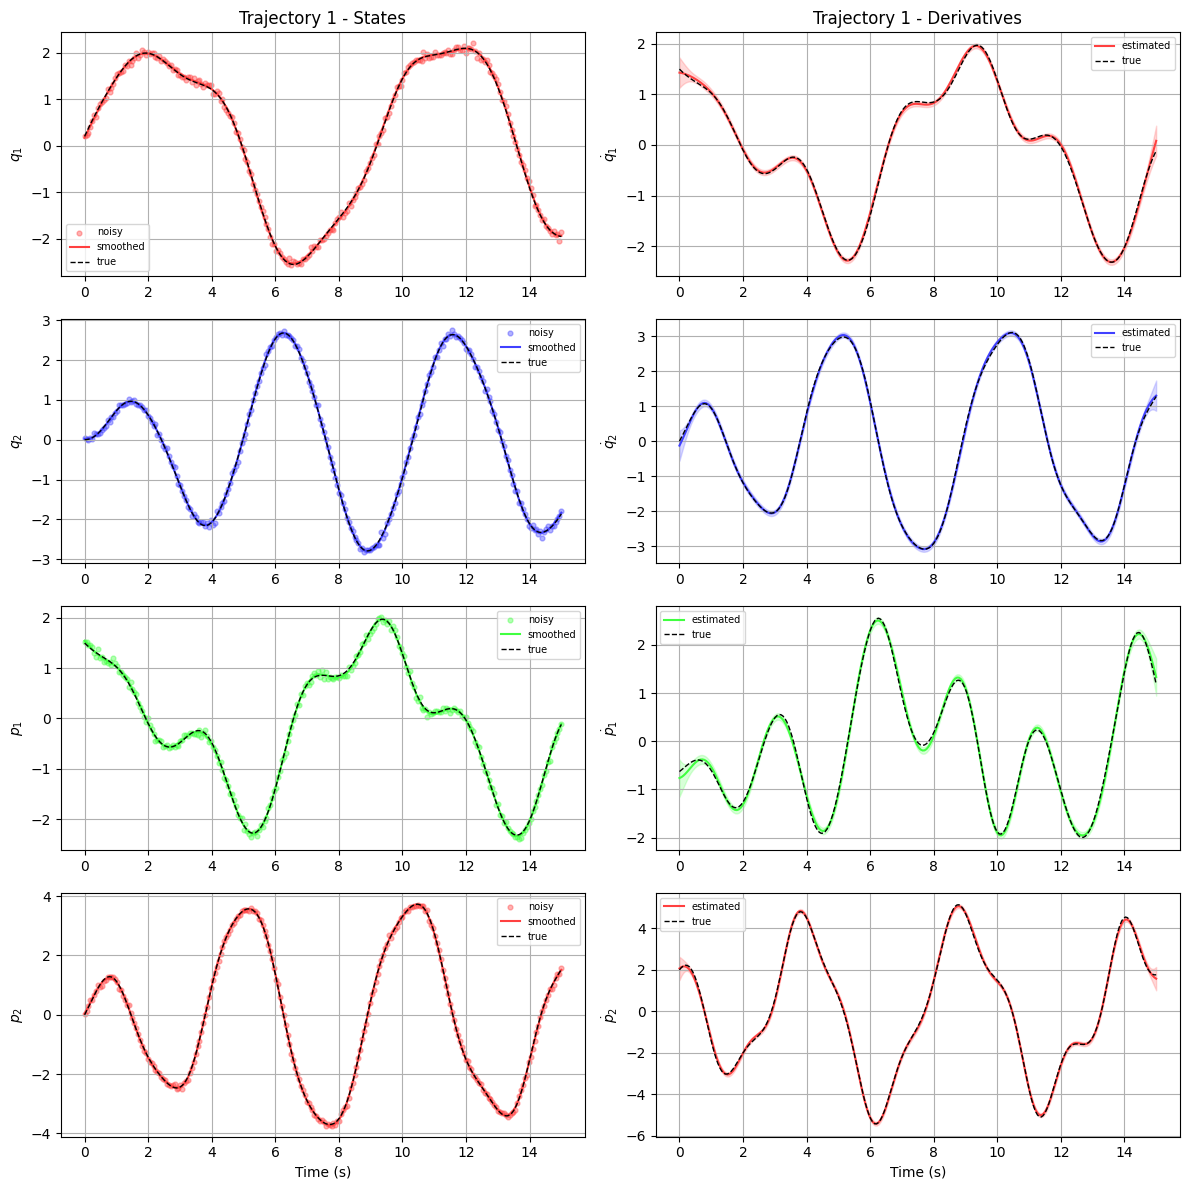

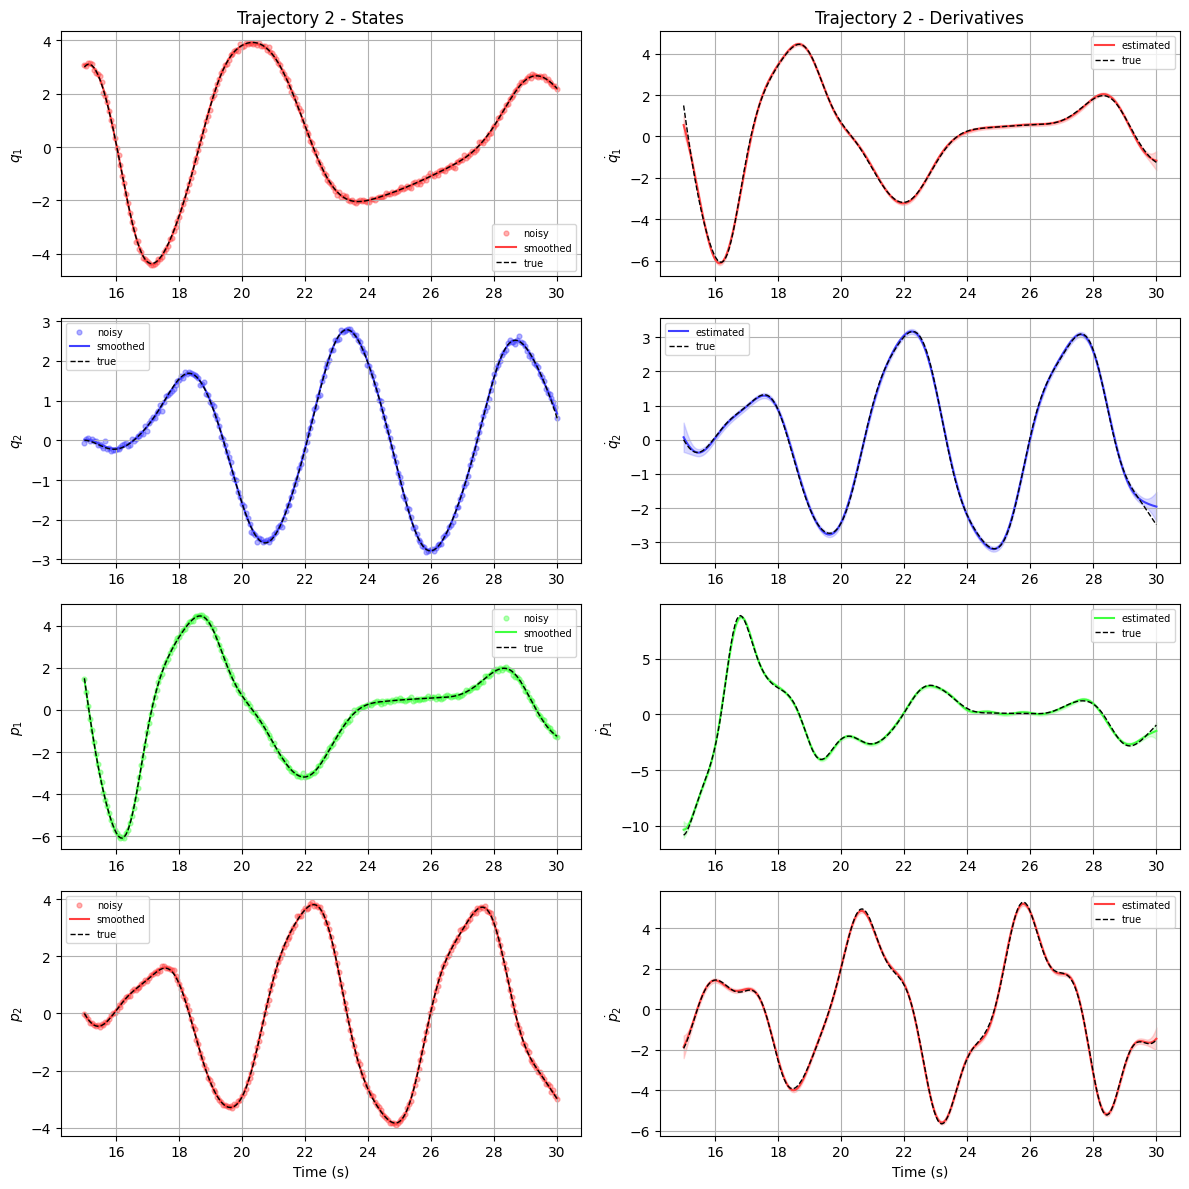

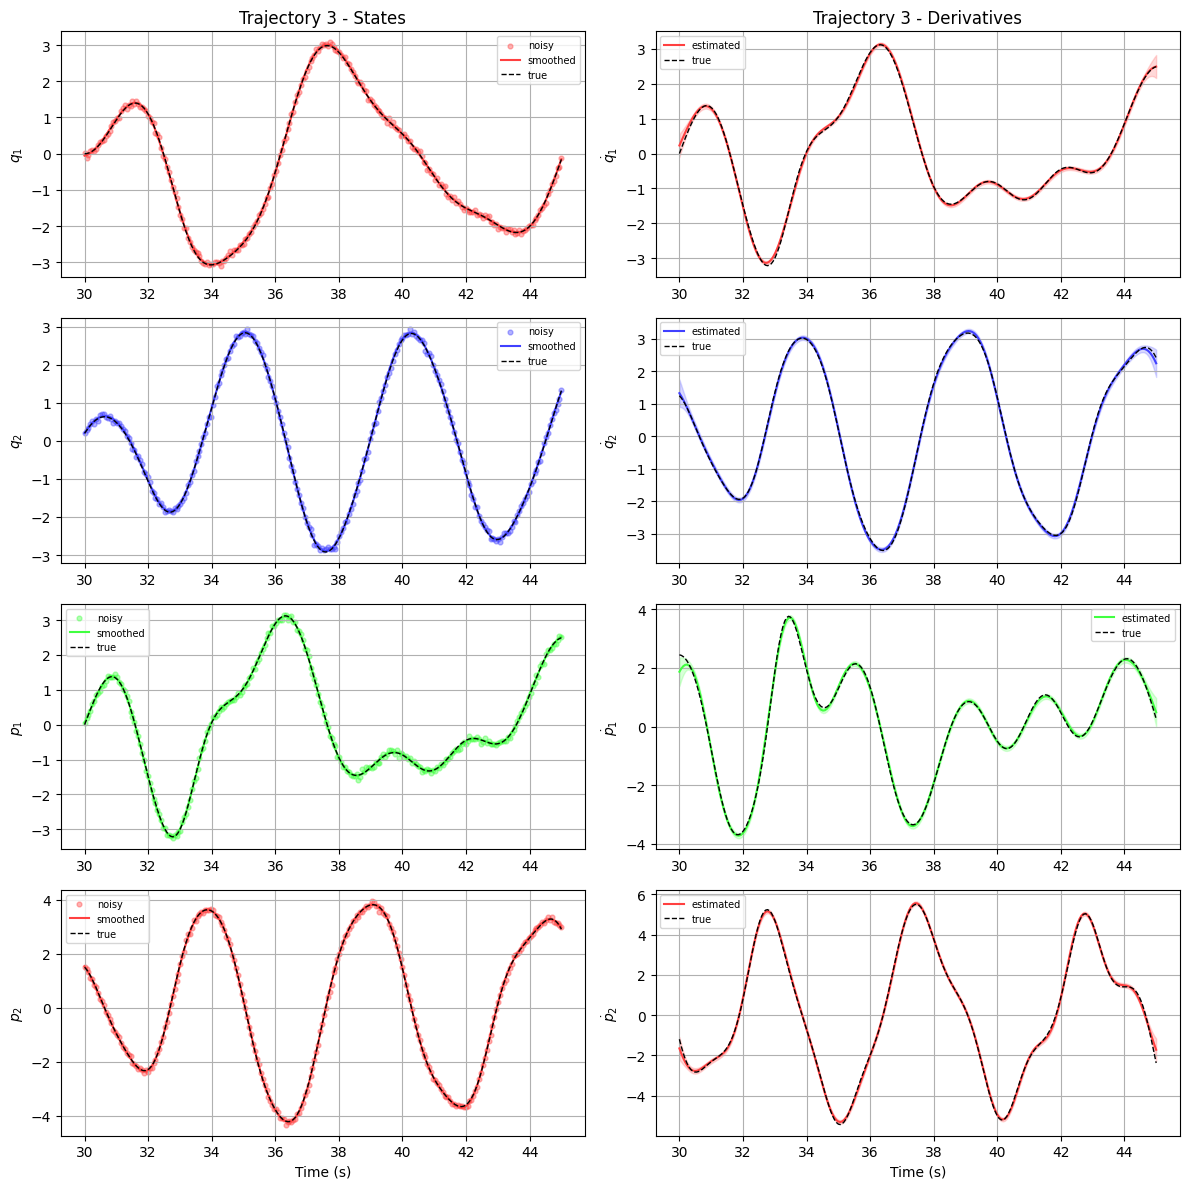

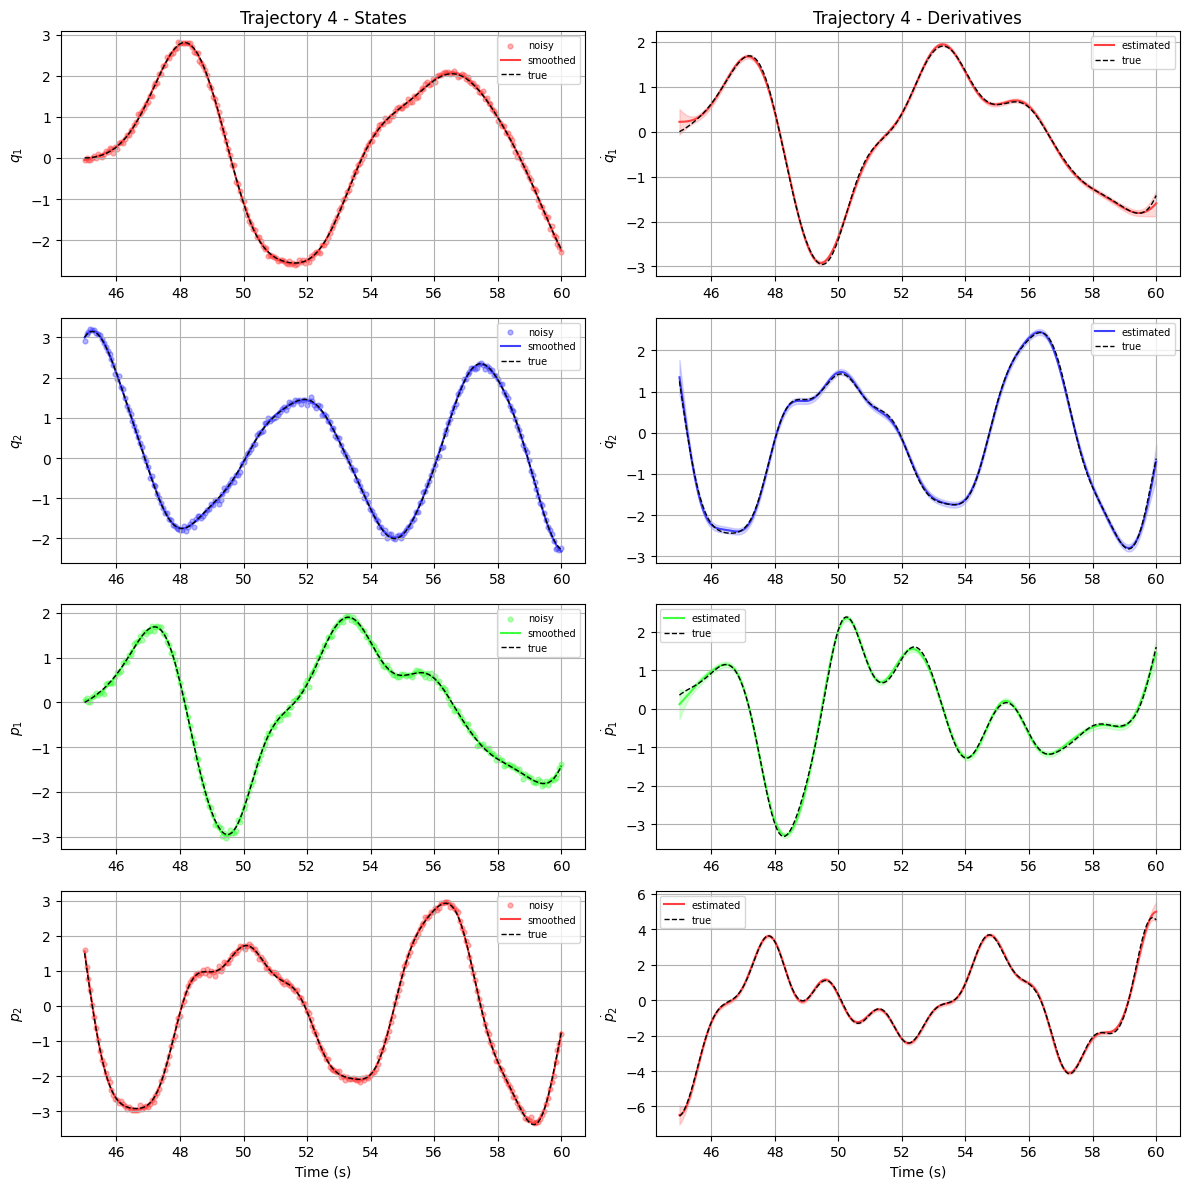

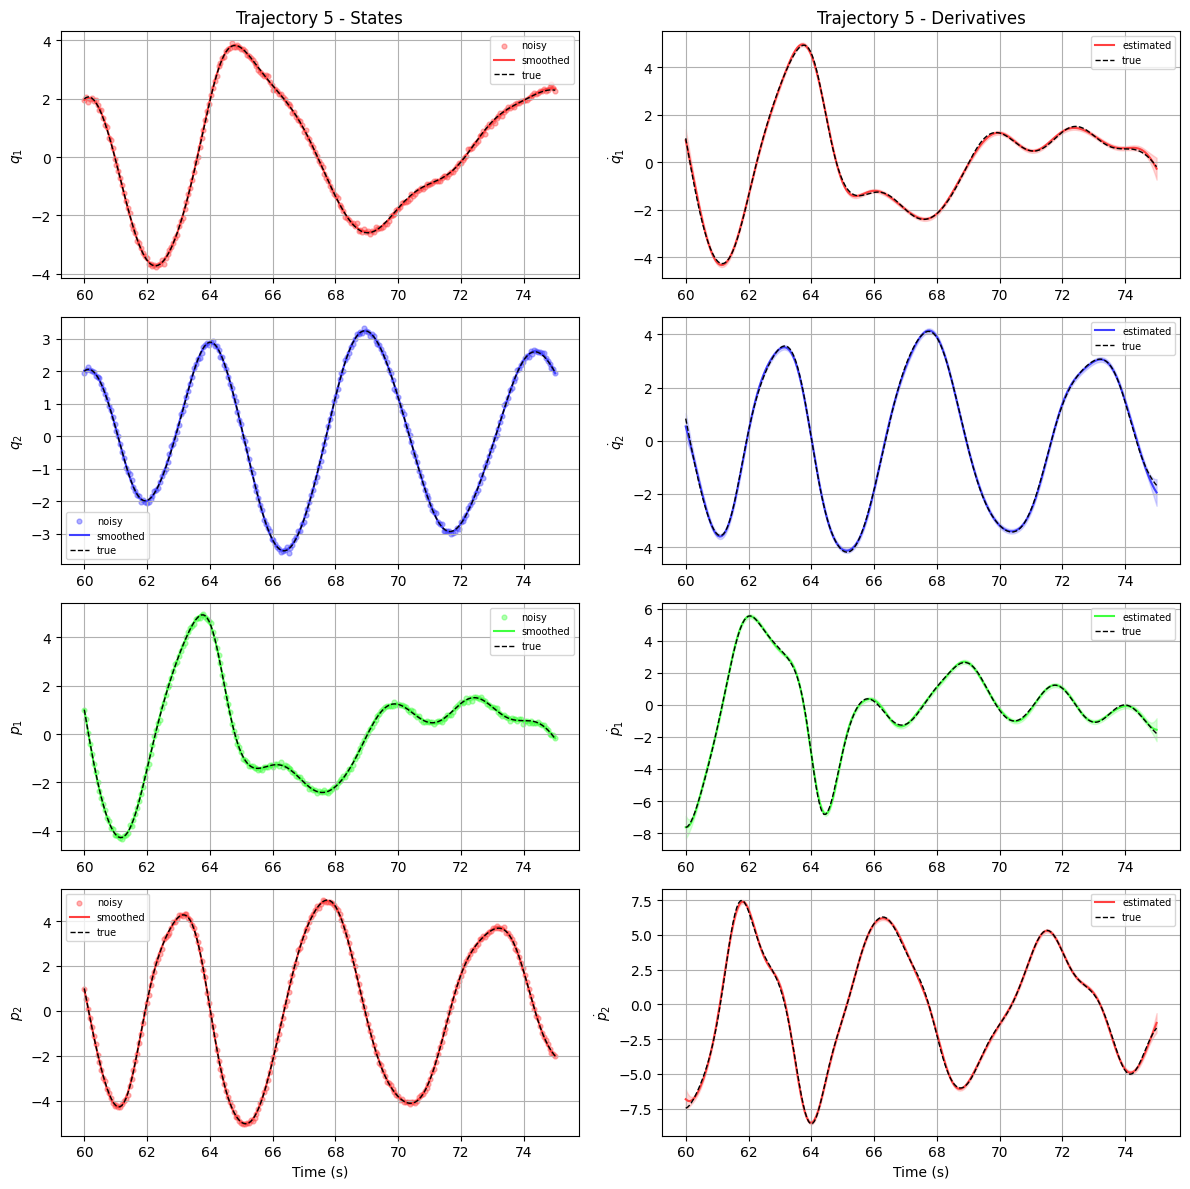

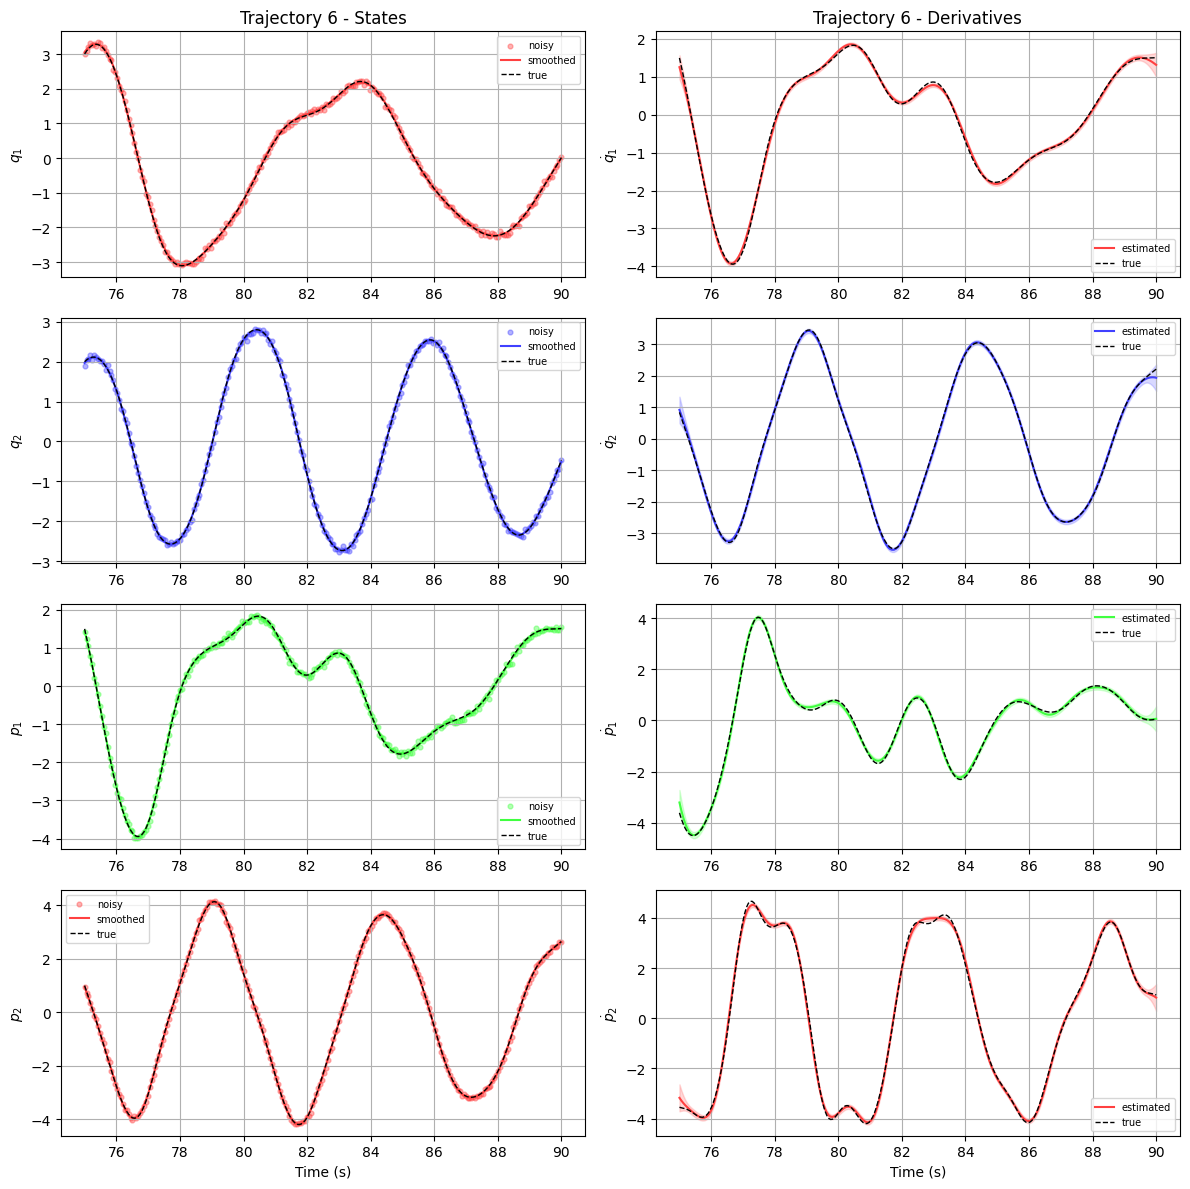

In [125]:
plot.pltGPSmooth(
    t_all,
    trajs,
    smoothed,
    xdots,
    xdot_vars,
    x_trues=trajs_true,
    dynamics=dynamics,
    sigs=sigs,
    state_lbls=[r'$q_1$', r'$q_2$', r'$p_1$', r'$p_2$'],
    deriv_lbls=[r'$\dot{q}_1$', r'$\dot{q}_2$', r'$\dot{p}_1$', r'$\dot{p}_2$'],
)

## Step 2: PHS Structure

Define 7 learnable parameters with appropriate constraints (log parameterization for positivity).

In [ ]:
# Raw tensors promoted to nn.Parameter by variable() — single canonical object per param
b1    = variable(torch.tensor([0.1], requires_grad=True), display_name='b1')
b2    = variable(torch.tensor([0.1], requires_grad=True), display_name='b2')
b3    = variable(torch.tensor([0.1], requires_grad=True), display_name='b3')
b4    = variable(torch.tensor([0.1], requires_grad=True), display_name='b4')
alpha = variable(torch.tensor([0.1], requires_grad=True), display_name='alpha')
beta  = variable(torch.tensor([0.1], requires_grad=True), display_name='beta')
gamma = variable(torch.tensor([0.1], requires_grad=True), display_name='gamma')

### Construct PHSMatrices

In [73]:
phs = gp_phs.PHSMatrices(
    nx=NX, nu=NU,
    J_upper={
        (0, 2): lambda x: torch.ones(x.shape[0]),
        (1, 3): lambda x: torch.ones(x.shape[0]),
        (2, 3): lambda x: alpha.value * x[:, 0] * x[:, 1]
    },
    R_diag={
        0: lambda x: torch.zeros(x.shape[0]),
        1: lambda x: torch.zeros(x.shape[0]),
        2: lambda x: (b1.value + b2.value * x[:, 0]**2) * torch.ones(x.shape[0]),
        3: lambda x: (b3.value + b4.value * x[:, 1]**2) * torch.ones(x.shape[0])
    },
    G_full={
        (2, 0): lambda x: 1.0 + beta.value  * x[:, 0]**2,
        (3, 1): lambda x: 1.0 + gamma.value * x[:, 1]**2
    }
)

## Step 3: Build Node, Loss, and Problem

In [74]:
# Constraints: makes sure R is PSD
x_var = variable('X')

con_R2 = (b1 + b2 * x_var[:, 0]**2 >= 0); con_R2.update_name('R2_nonneg')
con_R3 = (b3 + b4 * x_var[:, 1]**2 >= 0); con_R3.update_name('R3_nonneg')


# Build node
gpphs_module = gp_phs.GPPHSNode(phs, NX, NU)
gpphs_node = Node(gpphs_module, ['X', 'U', 'Xdot', 'Xdot_var'], ['nlml'], name='gp_phs')

# Objective
nlml = variable('nlml')
nlml_loss = nlml.minimize()
nlml_loss.name = 'nlml_loss'

# Aggregate and build problem
objectives  = [nlml_loss]
constraints = [con_R2, con_R3]

loss    = PenaltyLoss(objectives, constraints)
problem = Problem([gpphs_node], loss)

print('Problem created with:')
print(f'  {len(list(problem.parameters()))} total parameters')
print(f'  Objectives: {len(objectives)}')
print(f'  Constraints: {len(constraints)}')

Problem created with:
  10 total parameters
  Objectives: 1
  Constraints: 2


## Step 4: Training

In [75]:
optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)
logger    = BasicLogger(args=None, savedir='test', verbosity=1,
                        stdout=['train_loss', 'dev_loss'])
trainer   = Trainer(
    problem,
    train_loader,
    dev_loader,
    optimizer,
    epochs=N_EPOCHS,
    patience=N_EPOCHS,
    epoch_verbose=5,
    train_metric='train_loss',
    dev_metric='dev_loss',
    eval_metric='dev_loss',
    logger=logger,
)
for name, p in problem.named_parameters():
    print(name, p.shape)

None
Number of parameters: 13
nodes.0.callable.phs.J_2_3_alpha__value torch.Size([1])
nodes.0.callable.phs.R_2_b1__value torch.Size([1])
nodes.0.callable.phs.R_2_b2__value torch.Size([1])
nodes.0.callable.phs.R_3_b3__value torch.Size([1])
nodes.0.callable.phs.R_3_b4__value torch.Size([1])
nodes.0.callable.phs.G_2_0_beta__value torch.Size([1])
nodes.0.callable.phs.G_3_1_gamma__value torch.Size([1])
nodes.0.callable.likelihood.noise_covar.raw_noise torch.Size([1])
nodes.0.callable.gp_model.covar_module.raw_lengthscale torch.Size([4])
nodes.0.callable.gp_model.covar_module.raw_signal_var torch.Size([1])


In [76]:
# train
best_model = trainer.train()
problem.load_state_dict(best_model)

epoch: 0	train_loss: 745.72534	dev_loss: 203.22168	eltime:  4.51593
epoch: 1	train_loss: 297.76001	dev_loss: 190.46881	eltime:  7.97439
epoch: 2	train_loss: 122.14160	dev_loss: 147.32129	eltime:  10.86295
epoch: 3	train_loss: -43.64502	dev_loss: 136.48022	eltime:  14.72511
epoch: 4	train_loss: -187.96045	dev_loss: 96.48706	eltime:  17.70614
epoch: 5	train_loss: -326.99658	dev_loss: 89.66272	eltime:  20.75580
epoch: 6	train_loss: -452.15869	dev_loss: 52.16913	eltime:  23.52170
epoch: 7	train_loss: -582.34277	dev_loss: 45.61499	eltime:  26.40058
epoch: 8	train_loss: -697.26562	dev_loss: 10.32855	eltime:  29.46285
epoch: 9	train_loss: -820.24463	dev_loss: 3.93848	eltime:  32.62487
epoch: 10	train_loss: -924.92090	dev_loss: -29.19592	eltime:  35.63634
epoch: 11	train_loss: -1041.67529	dev_loss: -35.46033	eltime:  38.34442
epoch: 12	train_loss: -1136.08203	dev_loss: -66.56555	eltime:  41.14896
epoch: 13	train_loss: -1247.54248	dev_loss: -72.68860	eltime:  44.03161
epoch: 14	train_loss: -133

<All keys matched successfully>

### Parameter Recovery

In [77]:
gp_phs.param_table({
    'b₁': (b1, B1_TRUE),
    'b₂': (b2, B2_TRUE),
    'b₃': (b3, B3_TRUE),
    'b₄': (b4, B4_TRUE),
    'α':  (alpha, ALPHA_TRUE),
    'β':  (beta,  BETA_TRUE),
    'γ':  (gamma, GAMMA_TRUE),
})

Parameter  True  Learned  Rel. Error %
       b₁  0.15 0.153326      2.217431
       b₂  0.08 0.082386      2.982987
       b₃  0.12 0.119211      0.657871
       b₄  0.10 0.106911      6.910599
        α  0.05 0.044628     10.743268
        β  0.04 0.037961      5.096957
        γ  0.06 0.063172      5.286612

Mean relative error:   4.84%
Median relative error: 5.10%


,Parameter,True,Learned,Rel. Error %
0,b₁,0.15,0.153326,2.217431
1,b₂,0.08,0.082386,2.982987
2,b₃,0.12,0.119211,0.657871
3,b₄,0.10,0.106911,6.910599
4,α,0.05,0.044628,10.743268
5,β,0.04,0.037961,5.096957
6,γ,0.06,0.063172,5.286612


## Step 5: Hamiltonian Posterior

$H$ is identifiable up to an additive constant; the posterior mean is aligned to the true $H$ at training points.

### Compute posterior

In [137]:
# BUILD GP POSTERIOR
posterior = gpphs_node.callable.posterior()

# COMPUTE HAMILTONIAN POSTERIOR — all trajectories
H_mean, H_var, H_samples = posterior.predict(
    smoothed,
    us,
    xdots,
    xdot_vars,
    n_samples=50,
)

# Concatenate all trajectories for evaluation
x_all      = np.concatenate(smoothed, axis=0)
u_all      = np.concatenate(us, axis=0)
xdot_true  = np.concatenate(xdots, axis=0)
x_all_t    = torch.tensor(x_all, dtype=torch.float32)

# TRUE HAMILTONIAN — all trajectories
H_true_all = np.array([H_true(*row) for row in x_all])

### Plot Hamiltonian posterior

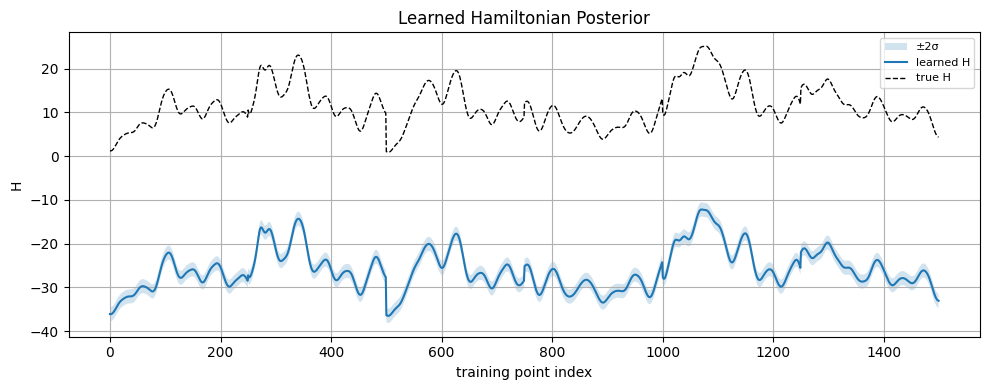

In [138]:
plot.pltHamiltonian(H_mean.numpy(), H_var.numpy(), H_true=H_true_all)

## Step 6: Callable $H^*$ Ensemble

Fit a GP interpolant to each posterior sample so $H^*$ can be evaluated and differentiated anywhere.

In [139]:
ensemble = [
    hamiltonian_approximator.HamiltonianApproximator(
        method='gp',
        lengthscale=posterior.lengthscale,
        signal_var=posterior.signal_var,
    ).fit(x_all_t, H_samples[i])
    for i in range(H_samples.shape[0])
]

## Step 7: Derivative Prediction

Verify that the learned model predicts $\dot{x} = (J(x) - R(x))\nabla H^*(x)$ correctly at training points before committing to full trajectory rollout.

In [140]:
# EVALUATE LEARNED DYNAMICS: ẋ = (J(x) - R(x))∇H*(x) + G(x)u
JR            = (phs.get_J(x_all_t) - phs.get_R(x_all_t)).detach().numpy()
G             = phs.get_G(x_all_t).detach().numpy()
grad_H_stack  = torch.stack([h.gradient(x_all_t) for h in ensemble])
grad_H_mean   = grad_H_stack.mean(0).detach().numpy()
grad_H_std    = grad_H_stack.std(0).detach().numpy()
xdot_pred     = np.einsum('nij,nj->ni', JR, grad_H_mean) + np.einsum('nij,nj->ni', G, u_all)
xdot_pred_std = np.einsum('nij,nj->ni', JR, grad_H_std)


### Plot

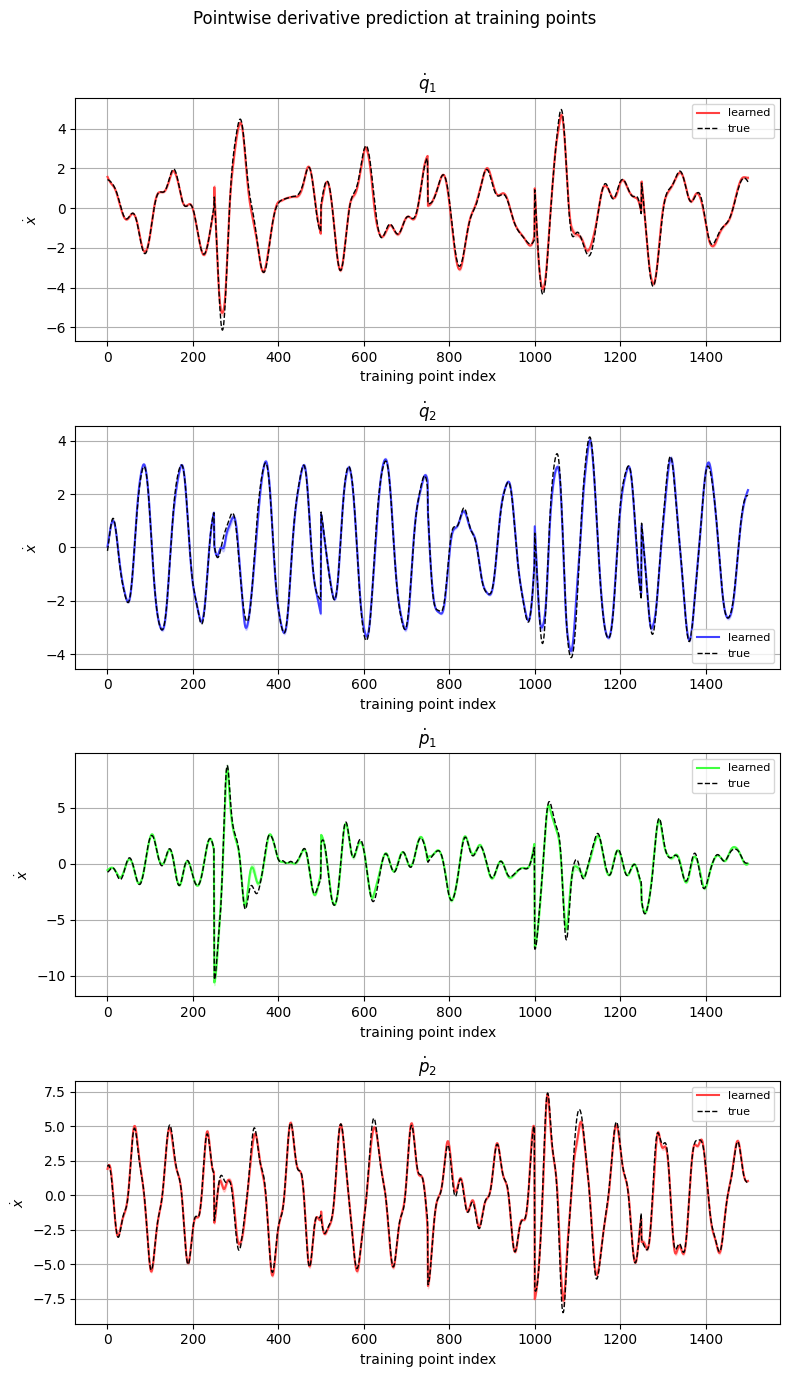

In [141]:
plot.pltXdot(
    xdot_pred, xdot_true,
    xdot_std=xdot_pred_std,
    state_lbls=[r'$\dot{q}_1$', r'$\dot{q}_2$', r'$\dot{p}_1$', r'$\dot{p}_2$'],
)

## Step 8: Trajectory Prediction

Simulate 10 trajectories (one per $H^*$ sample). Shaded band = $\pm 2$ std across the ensemble.

In [142]:
dt    = 0.01
t_sim = np.arange(0.0, T_SIM + dt, dt)

u_sim = torch.tensor(
    np.array([input_signal(t) for t in t_sim]),
    dtype=torch.float32,
).unsqueeze(1)

# True reference trajectories — all initial conditions
traj_sims = [
    odeint(lambda state, t: dynamics(state, t, input_signal), x0, t_sim)
    for x0 in X0_TEST
]

# Simulate learned GP-PHS from all initial conditions
phsode = ode.PHSODE(phs, ensemble, NX, NU, method='rk4')
with torch.no_grad():
    result = phsode.simulate(
        x0=torch.tensor(X0_TEST, dtype=torch.float32),
        t_span=(0.0, T_SIM),
        u=u_sim.expand(-1, len(X0_TEST), -1),
        dt=dt,
    )

t_gp = result['t_eval'].numpy()
mean = result['mean'].numpy()   # (T, N, nx)
std  = result['std'].numpy()    # (T, N, nx)

### Plot trajectory prediction

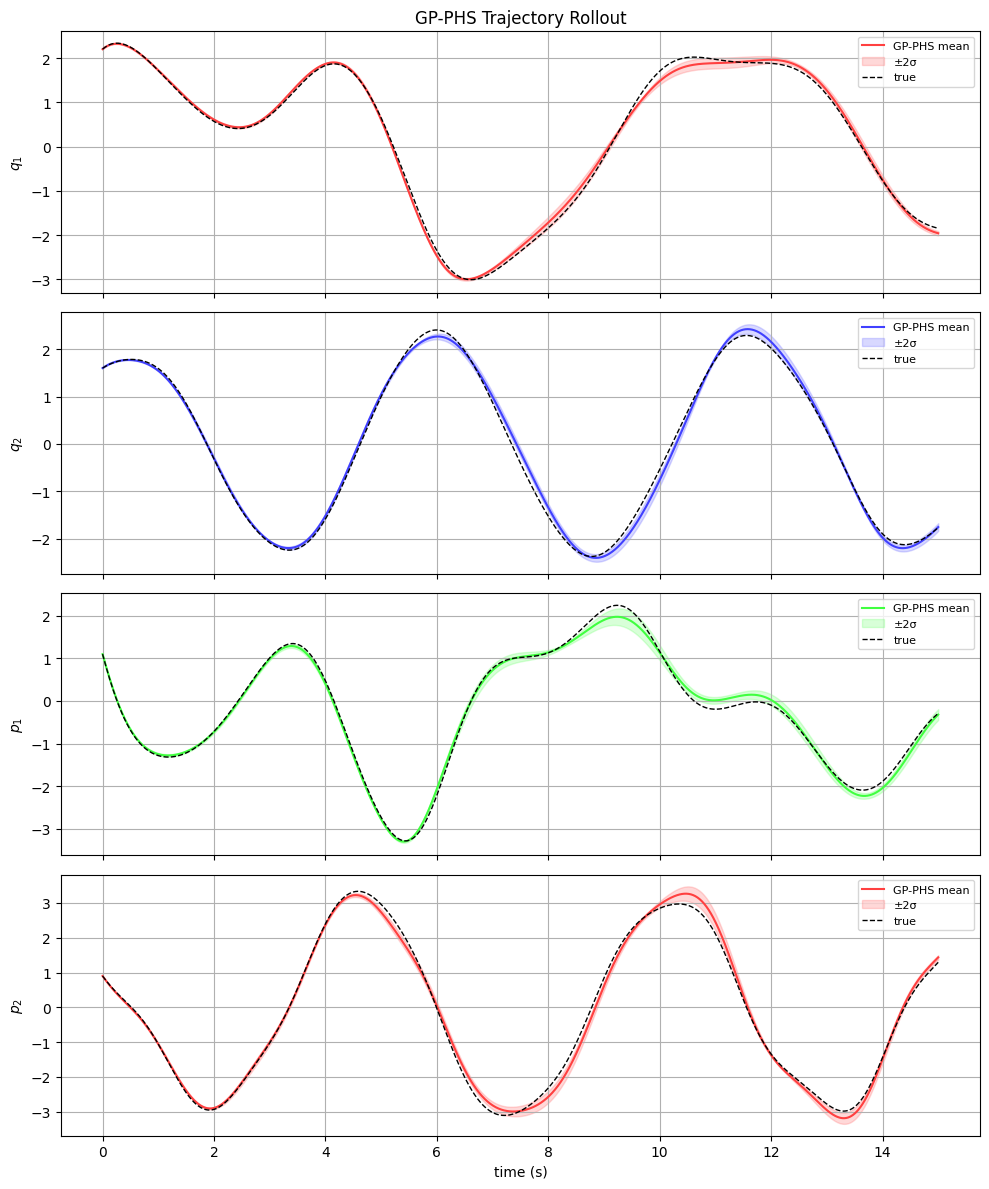

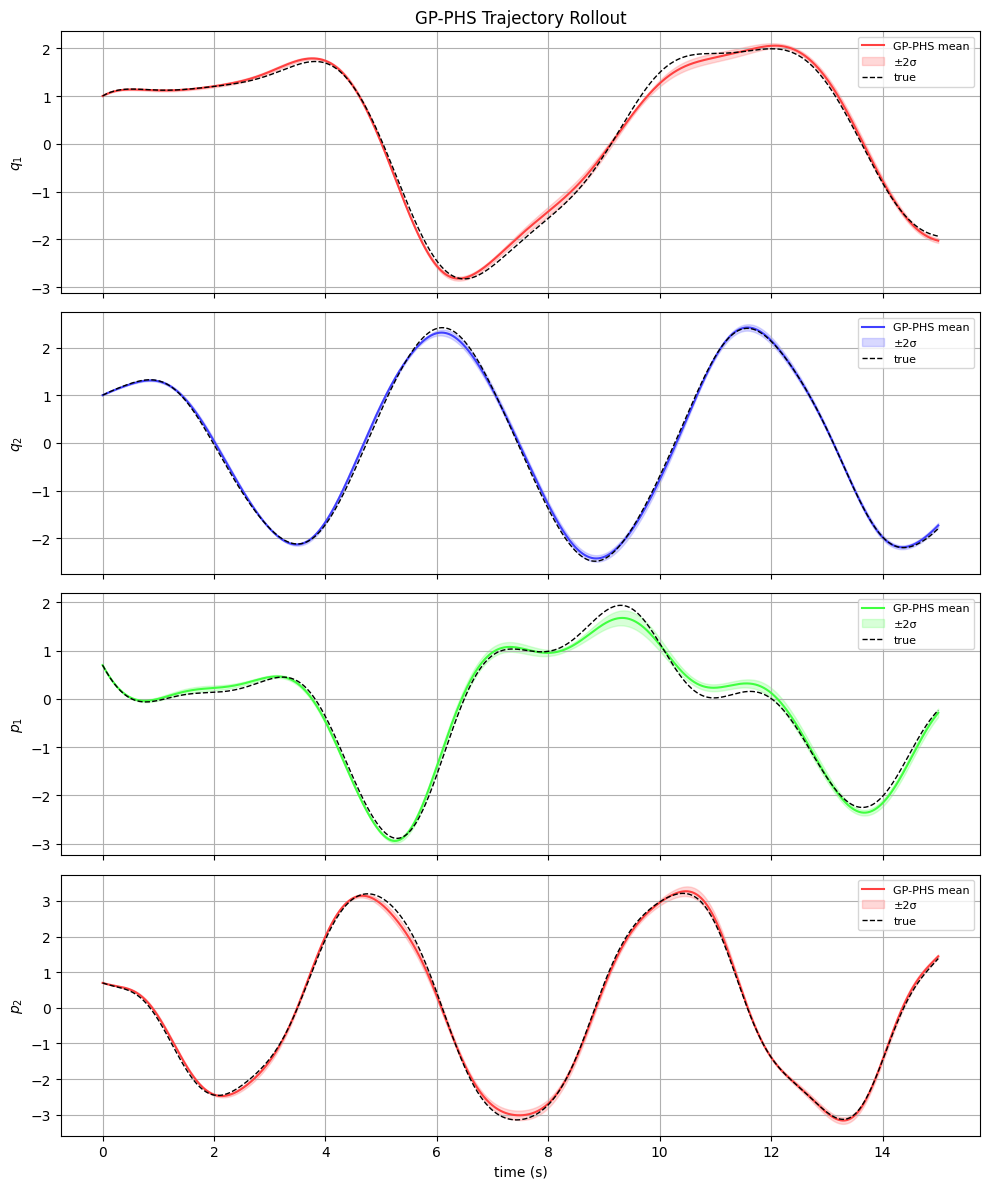

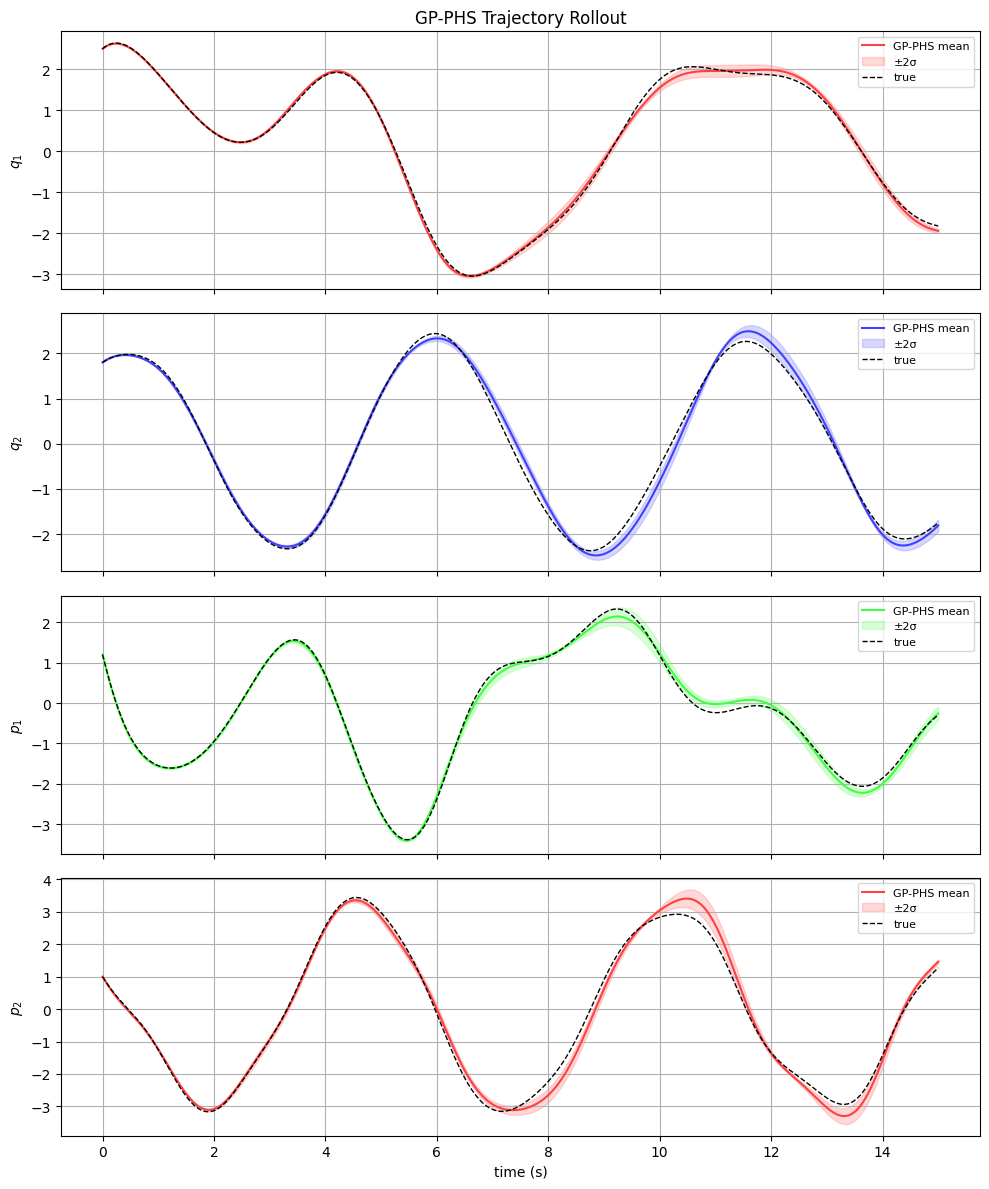

In [136]:
for i in range(len(X0_TEST)):
    plot.pltTrajectory(
        t_gp,
        mean[:, i, :],
        std=std[:, i, :],
        x_true=traj_sims[i],
        state_lbls=[r'$q_1$', r'$q_2$', r'$p_1$', r'$p_2$'],
        figname=f"traj_{i}",
    )